In [47]:
import pandas as pd
import numpy as np
from pathlib import Path

# Set random seed to reproducible
np.random.seed(42)

# Check file size
file_size_gb = Path("NYCTLC.csv").stat().st_size / (1024**3)
print(f"File size: {file_size_gb:.2f} GB")

File size: 12.42 GB


In [48]:
total_rows = 0
for chunk in pd.read_csv("NYCTLC.csv", chunksize=500000, usecols=['PULocationID']):
    total_rows += len(chunk)

print(f"Total Rows: {total_rows:,}")

Total Rows: 84,226,744


In [49]:
sample_check = pd.read_csv("NYCTLC.csv", nrows=1000)
print("Columns:", sample_check.columns.tolist())
print("\nDtypes:")
print(sample_check.dtypes)
sample_check.head()

Columns: ['congestion_surcharge (Capped)', 'trip_duration_minutes (Capped)', 'trip_duration_minutes', 'tolls_amount (Capped)', 'total_amount (Capped)', 'tip_amount (Capped)', 'mta_tax (Capped)', 'extra (Capped)', 'passenger_count (Capped)', 'trip_distance (Capped)', 'fare_amount (Capped)', 'VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'File Paths']

Dtypes:
congestion_surcharge (Capped)       int64
trip_duration_minutes (Capped)      int64
trip_duration_minutes               int64
tolls_amount (Capped)             float64
total_amount (Capped)             float64
tip_amount (Capped)               float64
mta_tax (Capped)                  float64
extra (Capped)                    float64
passenger_count (Capped)            int

,congestion_surcharge (Capped),trip_duration_minutes (Capped),trip_duration_minutes,tolls_amount (Capped),total_amount (Capped),tip_amount (Capped),mta_tax (Capped),extra (Capped),passenger_count (Capped),trip_distance (Capped),...,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,File Paths
0,0,35,35,0.0,33.80,0.00,0.5,0.0,1,9.01,...,2,33.0,0.0,0.5,0.00,0.0,0.3,33.80,NaN,yellow_tripdata_2019-01.csv
1,0,6,6,0.0,7.30,0.00,0.5,0.0,1,1.27,...,2,6.5,0.0,0.5,0.00,0.0,0.3,7.30,NaN,yellow_tripdata_2019-01.csv
2,0,4,4,0.0,6.80,0.00,0.5,0.0,1,1.21,...,2,6.0,0.0,0.5,0.00,0.0,0.3,6.80,NaN,yellow_tripdata_2019-01.csv
3,0,5,5,0.0,7.80,0.00,0.5,0.0,1,1.98,...,2,7.0,0.0,0.5,0.00,0.0,0.3,7.80,NaN,yellow_tripdata_2019-01.csv
4,0,2,2,0.0,6.96,1.16,0.5,0.0,1,0.91,...,1,5.0,0.0,0.5,1.16,0.0,0.3,6.96,NaN,yellow_tripdata_2019-01.csv


In [ ]:
CHUNK_SIZE = 500_000 #each month sampled by 500K
SAMPLE_FRACTION = 0.06  # ~6% = 5M rows for file 84M
OUTPUT_FILE = "NYCTLC_Stratified_Sample.csv"

# Keep add-valued column (Using Capped versions)
COLUMNS_TO_KEEP = [
    'tpep_pickup_datetime',
    'PULocationID',
    'passenger_count (Capped)',
    'trip_distance (Capped)',
    'fare_amount (Capped)',
    'tip_amount (Capped)',
    'total_amount (Capped)',
    'trip_duration_minutes (Capped)',
    'payment_type',
    'RatecodeID'
]
def parse_vietnamese_datetime(series):
    # Replace SA -> AM, CH -> PM
    series = series.astype(str).str.replace(' SA', ' AM').str.replace(' CH', ' PM')
    # Parse by format DD/MM/YYYY
    return pd.to_datetime(series, format='%d/%m/%Y %I:%M:%S %p', errors='coerce')

if Path(OUTPUT_FILE).exists():
    Path(OUTPUT_FILE).unlink()
    print("Removed old output file")
    
sampled_chunks = []
total_processed = 0
total_sampled = 0
header_written = False
error_chunks = 0

print("Starting chunked stratified sampling...")
print("="*60)

#Read Errors
reader = pd.read_csv(
    "NYCTLC.csv",
    chunksize=CHUNK_SIZE,
    usecols=COLUMNS_TO_KEEP,
    on_bad_lines='skip',        # Skip bad lines instead of stop
    encoding='utf-8',
    encoding_errors='ignore',    # Ignore encoding errors
    low_memory=False
    )

 # Create 'Month''HourOfDay''DayOfWeek' for Stratified Sampling
for i, chunk in enumerate(reader):
    pickup_dt = parse_vietnamese_datetime(chunk['tpep_pickup_datetime'])
    chunk['Month'] = pickup_dt.dt.month
    chunk['HourOfDay'] = pickup_dt.dt.hour
    chunk['DayOfWeek'] = pickup_dt.dt.dayofweek
   
    # Drop rows datetime errors
    chunk = chunk.dropna(subset=['Month'])
    if len(chunk) == 0:
            error_chunks += 1
            continue
    
    #Stratified Sampling by Month + PULocationID
    sampled = chunk.groupby(['Month', 'PULocationID'], group_keys=False).apply(
            lambda x: x.sample(frac=SAMPLE_FRACTION, random_state=42) if len(x) > 0 else x
        )
    
    sampled.to_csv(OUTPUT_FILE, mode='a', header=not header_written, index=False)

    header_written = True
    
    total_processed += len(chunk)
    total_sampled += len(sampled)

    if (i + 1) % 10 == 0:
            print(f"Chunk {i+1}: processed {total_processed:,} | sampled {total_sampled:,}")

print("\n" + "="*60)
print(f"Total processed: {total_processed:,}")
print(f"Total sampled: {total_sampled:,}")
print(f"Output: {OUTPUT_FILE}")
print(f"File size: {Path(OUTPUT_FILE).stat().st_size / (1024**3):.2f} GB")

Starting chunked stratified sampling...


/var/folders/gz/bhnd7cjx3jjcs6bngc07zzyw0000gn/T/ipykernel_78483/2603320454.py:62: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled = chunk.groupby(['Month', 'PULocationID'], group_keys=False).apply(
/var/folders/gz/bhnd7cjx3jjcs6bngc07zzyw0000gn/T/ipykernel_78483/2603320454.py:62: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled = chunk.groupby(['Month', 'PULocationID'], group_keys=False).apply(
/var/folde

Chunk 10: processed 5,000,000 | sampled 299,990


/var/folders/gz/bhnd7cjx3jjcs6bngc07zzyw0000gn/T/ipykernel_78483/2603320454.py:62: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled = chunk.groupby(['Month', 'PULocationID'], group_keys=False).apply(
/var/folders/gz/bhnd7cjx3jjcs6bngc07zzyw0000gn/T/ipykernel_78483/2603320454.py:62: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled = chunk.groupby(['Month', 'PULocationID'], group_keys=False).apply(
/var/folde

Chunk 20: processed 10,000,000 | sampled 599,970


...

/var/folders/gz/bhnd7cjx3jjcs6bngc07zzyw0000gn/T/ipykernel_78483/2603320454.py:62: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled = chunk.groupby(['Month', 'PULocationID'], group_keys=False).apply(
/var/folders/gz/bhnd7cjx3jjcs6bngc07zzyw0000gn/T/ipykernel_78483/2603320454.py:62: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled = chunk.groupby(['Month', 'PULocationID'], group_keys=False).apply(
/var/folde

Chunk 160: processed 80,000,000 | sampled 4,799,264


/var/folders/gz/bhnd7cjx3jjcs6bngc07zzyw0000gn/T/ipykernel_78483/2603320454.py:62: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled = chunk.groupby(['Month', 'PULocationID'], group_keys=False).apply(
/var/folders/gz/bhnd7cjx3jjcs6bngc07zzyw0000gn/T/ipykernel_78483/2603320454.py:62: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled = chunk.groupby(['Month', 'PULocationID'], group_keys=False).apply(
/var/folde


Total processed: 84,226,744
Total sampled: 5,052,828
Output: NYCTLC_Stratified_Sample.csv
File size: 0.28 GB


/var/folders/gz/bhnd7cjx3jjcs6bngc07zzyw0000gn/T/ipykernel_78483/2603320454.py:62: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled = chunk.groupby(['Month', 'PULocationID'], group_keys=False).apply(


In [51]:
import pandas as pd

df = pd.read_csv("NYCTLC_Stratified_Sample.csv")  # New File

print(f"Total rows: {len(df):,}")
print(f"Unique zones: {df['PULocationID'].nunique()} / 263")

print("\nRows by Month:")
print(df['Month'].value_counts().sort_index())

print("\nMonth x Zone coverage:")
print(f"{df.groupby(['Month', 'PULocationID']).ngroups} / 3156")

Total rows: 5,052,828
Unique zones: 242 / 263

Rows by Month:
Month
1     460029
2     421115
3     469953
4     445929
5     453858
6     416375
7     378577
8     364317
9     393996
10    432706
11    412552
12    403421
Name: count, dtype: int64

Month x Zone coverage:
2751 / 3156


In [52]:
import pandas as pd
from pathlib import Path

# Read Sample File
df = pd.read_csv("NYCTLC_Stratified_Sample.csv")

# Rename Columns
df = df.rename(columns={
    'passenger_count (Capped)': 'passenger_count',
    'trip_distance (Capped)': 'trip_distance',
    'fare_amount (Capped)': 'fare_amount',
    'tip_amount (Capped)': 'tip_amount',
    'total_amount (Capped)': 'total_amount',
    'trip_duration_minutes (Capped)': 'trip_duration_minutes'
})

# Export
df.to_csv("NYCTLC_Stratified_Sample.csv", index=False)

print(f"Renamed columns successfully")
print(f"Total rows: {len(df):,}")
print(f"New columns: {df.columns.tolist()}")

Renamed columns successfully
Total rows: 5,052,828
New columns: ['trip_duration_minutes', 'total_amount', 'tip_amount', 'passenger_count', 'trip_distance', 'fare_amount', 'tpep_pickup_datetime', 'RatecodeID', 'PULocationID', 'payment_type', 'Month', 'HourOfDay', 'DayOfWeek']


In [54]:
import sys
!{sys.executable} -m pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 7.8 MB 1.3 MB/s eta 0:00:01
     |████████████████████████████████| 249 kB 1.6 MB/s eta 0:00:01
     |████████████████████████████████| 64 kB 4.9 MB/s eta 0:00:01
     |████████████████████████████████| 4.7 MB 2.5 MB/s eta 0:00:01
     |████████████████████████████████| 122 kB 4.8 MB/s eta 0:00:01
     |████████████████████████████████| 2.9 MB 2.2 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


Loaded: 5,052,828 rows


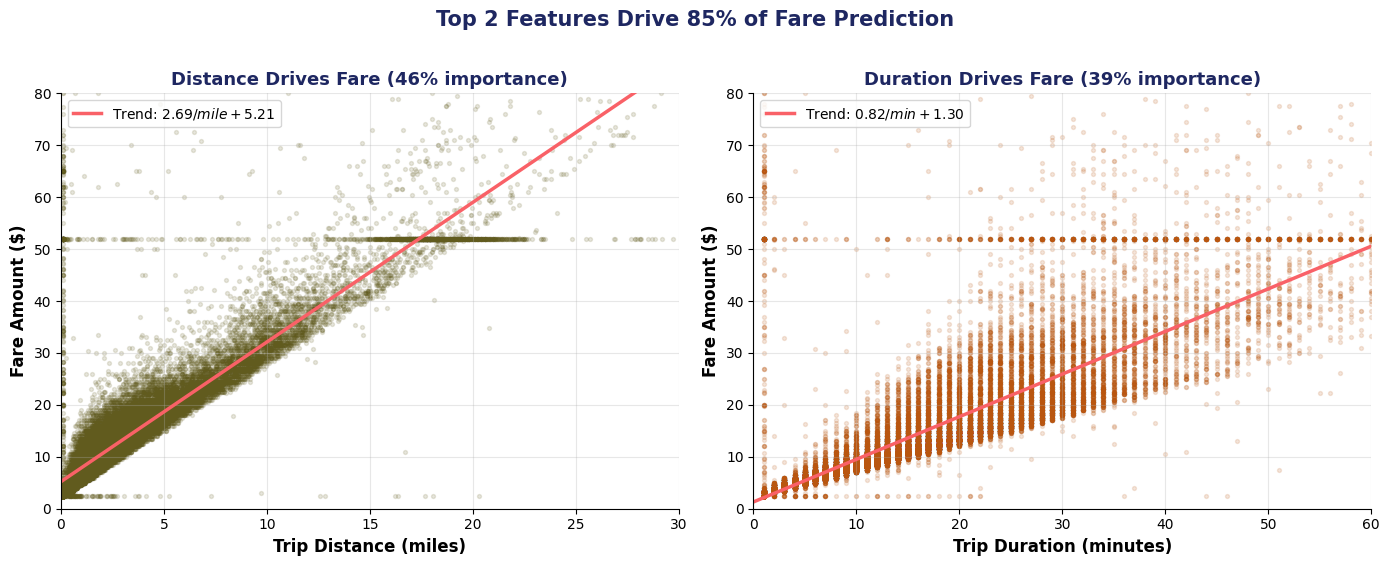

✅ Saved: distance_duration_vs_fare.png


In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load file sample 5M
df = pd.read_csv("NYCTLC_Stratified_Sample.csv")
print(f"Loaded: {len(df):,} rows")

# Sample 50K rows để scatter plot không quá nặng
df_plot = df.sample(50000, random_state=42)

# Tạo figure với 2 scatter plots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# === Plot 1: Distance vs Fare ===
axes[0].scatter(df_plot['trip_distance'], df_plot['fare_amount'], 
                alpha=0.15, s=8, color="#615B1E")
axes[0].set_xlabel('Trip Distance (miles)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Fare Amount ($)', fontsize=12, fontweight='bold')
axes[0].set_title('Distance Drives Fare (46% importance)', 
                   fontsize=13, fontweight='bold', color='#1E2761')
axes[0].set_xlim(0, 30)
axes[0].set_ylim(0, 80)
axes[0].grid(True, alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Add trend line
z = np.polyfit(df_plot['trip_distance'].clip(0, 30), 
               df_plot['fare_amount'].clip(0, 80), 1)
p = np.poly1d(z)
x_line = np.linspace(0, 30, 100)
axes[0].plot(x_line, p(x_line), color='#F96167', linewidth=2.5, 
             label=f'Trend: ${z[0]:.2f}/mile + ${z[1]:.2f}')
axes[0].legend(loc='upper left', fontsize=10)

# === Plot 2: Duration vs Fare ===
axes[1].scatter(df_plot['trip_duration_minutes'], df_plot['fare_amount'], 
                alpha=0.15, s=8, color="#B95610")
axes[1].set_xlabel('Trip Duration (minutes)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Fare Amount ($)', fontsize=12, fontweight='bold')
axes[1].set_title('Duration Drives Fare (39% importance)', 
                   fontsize=13, fontweight='bold', color='#1E2761')
axes[1].set_xlim(0, 60)
axes[1].set_ylim(0, 80)
axes[1].grid(True, alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Add trend line
z2 = np.polyfit(df_plot['trip_duration_minutes'].clip(0, 60), 
                df_plot['fare_amount'].clip(0, 80), 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(0, 60, 100)
axes[1].plot(x_line2, p2(x_line2), color='#F96167', linewidth=2.5,
             label=f'Trend: ${z2[0]:.2f}/min + ${z2[1]:.2f}')
axes[1].legend(loc='upper left', fontsize=10)

# Main title
fig.suptitle('Top 2 Features Drive 85% of Fare Prediction', 
             fontsize=15, fontweight='bold', color='#1E2761', y=1.02)

plt.tight_layout()
plt.savefig('distance_duration_vs_fare.png', dpi=200, bbox_inches='tight', 
            facecolor='white')
plt.show()
print("✅ Saved: distance_duration_vs_fare.png")

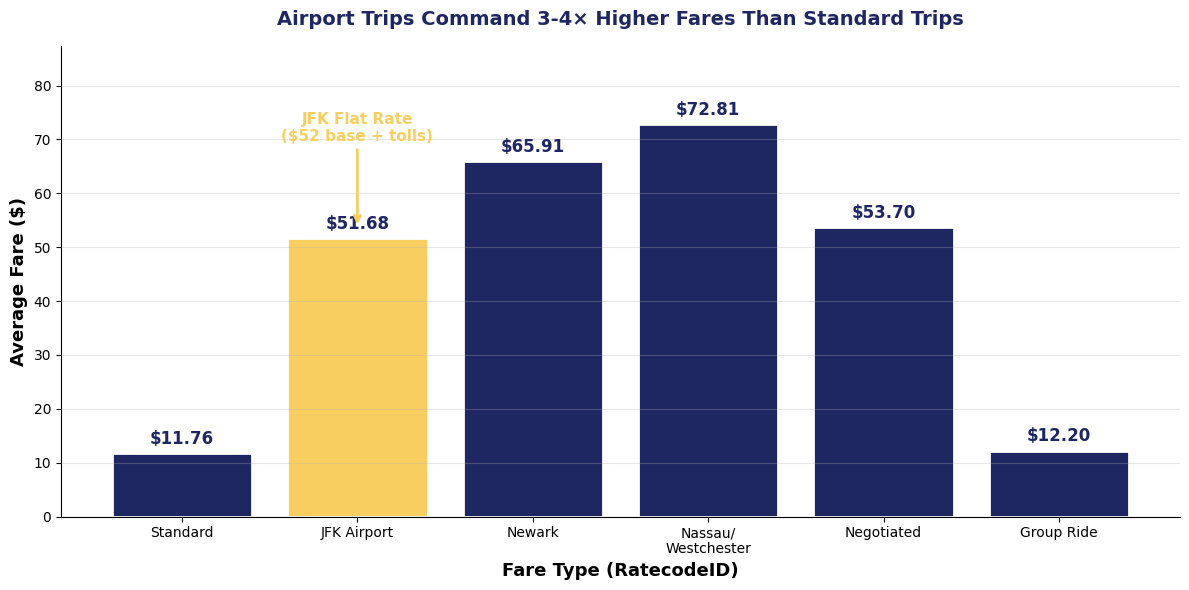

✅ Saved: airport_premium.png


In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("NYCTLC_Stratified_Sample.csv")

ratecode_labels = {
    1: 'Standard',
    2: 'JFK Airport',
    3: 'Newark',
    4: 'Nassau/\nWestchester',
    5: 'Negotiated',
    6: 'Group Ride'
}

avg_fare_by_rate = df.groupby('RatecodeID')['fare_amount'].agg(['mean', 'count']).reset_index()
avg_fare_by_rate['Type'] = avg_fare_by_rate['RatecodeID'].map(ratecode_labels)
avg_fare_by_rate = avg_fare_by_rate[avg_fare_by_rate['RatecodeID'].isin([1,2,3,4,5,6])]

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#1E2761' if x != 2 else "#F9CE61" for x in avg_fare_by_rate['RatecodeID']]

bars = ax.bar(avg_fare_by_rate['Type'], avg_fare_by_rate['mean'],
              color=colors, edgecolor='white', linewidth=2)

for bar, val in zip(bars, avg_fare_by_rate['mean']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'${val:.2f}', ha='center', va='bottom',
            fontsize=12, fontweight='bold', color='#1E2761')

ax.set_ylabel('Average Fare ($)', fontsize=13, fontweight='bold')
ax.set_xlabel('Fare Type (RatecodeID)', fontsize=13, fontweight='bold')
ax.set_title('Airport Trips Command 3-4× Higher Fares Than Standard Trips',
             fontsize=14, fontweight='bold', color='#1E2761', pad=15)
ax.set_ylim(0, max(avg_fare_by_rate['mean']) * 1.2)
ax.grid(True, alpha=0.3, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# FIX: Annotation JFK gần hơn (ngay phía trên cột JFK)
jfk_value = avg_fare_by_rate[avg_fare_by_rate['RatecodeID']==2]['mean'].values[0]
ax.annotate('JFK Flat Rate\n($52 base + tolls)',
            xy=(1, jfk_value + 2), xytext=(1, jfk_value + 18),
            fontsize=11, color="#F9CE61", fontweight='bold',
            ha='center',
            arrowprops=dict(arrowstyle='->', color="#F9CE61", lw=2))

plt.tight_layout()
plt.savefig('airport_premium.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: airport_premium.png")

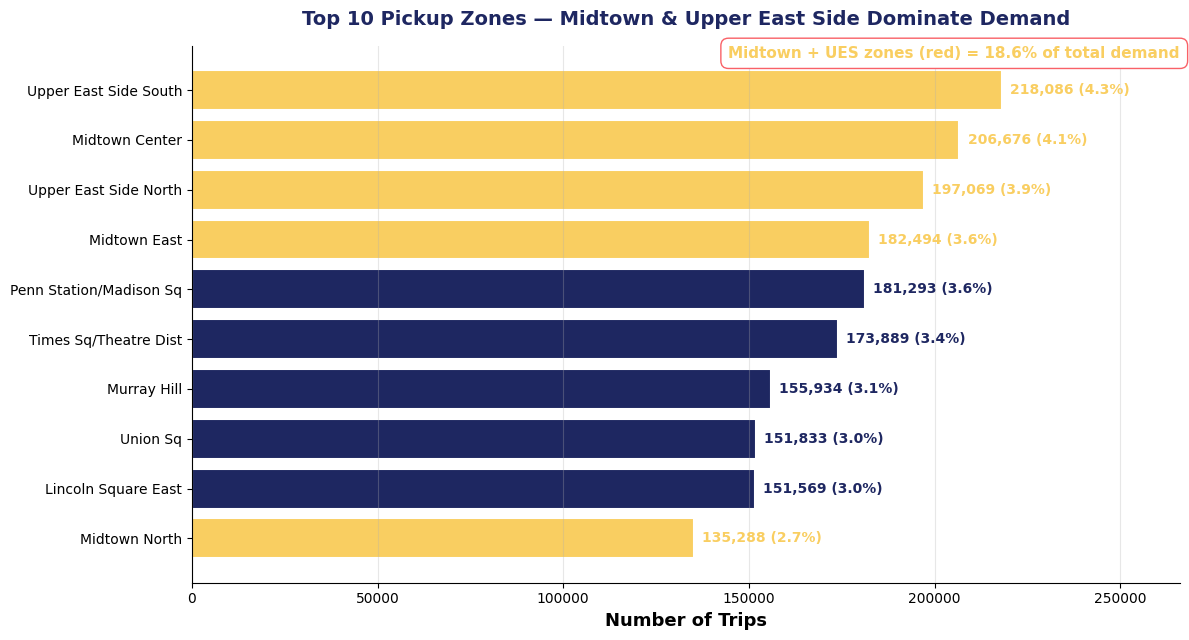

✅ Saved: spatial_patterns.png


In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("NYCTLC_Stratified_Sample.csv")

# Chỉ giữ named zones (bỏ "Other" để tránh overlap)
zone_names = {
    237: 'Upper East Side South',
    161: 'Midtown Center',
    236: 'Upper East Side North',
    162: 'Midtown East',
    186: 'Penn Station/Madison Sq',
    230: 'Times Sq/Theatre Dist',
    170: 'Murray Hill',
    142: 'Lincoln Square East',
    234: 'Union Sq',
    163: 'Midtown North'
}

# Filter chỉ giữ zones có tên trong dict
df_named = df[df['PULocationID'].isin(zone_names.keys())]
top_zones = df_named['PULocationID'].value_counts().reset_index()
top_zones.columns = ['PULocationID', 'trip_count']
top_zones['Zone'] = top_zones['PULocationID'].map(zone_names)

total_trips = len(df)
top_zones['pct'] = (top_zones['trip_count'] / total_trips * 100)
top_zones = top_zones.sort_values('trip_count', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6.5))

midtown_ues_ids = [237, 161, 236, 162, 163]
colors = ["#F9CE61" if pid in midtown_ues_ids else '#1E2761' 
          for pid in top_zones['PULocationID']]

bars = ax.barh(top_zones['Zone'], top_zones['trip_count'],
               color=colors, edgecolor='white', linewidth=1.5)

# Labels ở cuối bars
for bar, count, pct, color in zip(bars, top_zones['trip_count'], top_zones['pct'], colors):
    width = bar.get_width()
    ax.text(width + max(top_zones['trip_count']) * 0.01, 
            bar.get_y() + bar.get_height()/2.,
            f'{count:,} ({pct:.1f}%)',
            ha='left', va='center', fontsize=10, color=color, fontweight='bold')

ax.set_xlabel('Number of Trips', fontsize=13, fontweight='bold')
ax.set_title('Top 10 Pickup Zones — Midtown & Upper East Side Dominate Demand',
             fontsize=14, fontweight='bold', color='#1E2761', pad=15)
ax.set_xlim(0, max(top_zones['trip_count']) * 1.22)
ax.grid(True, alpha=0.3, axis='x')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# FIX: Move annotation lên trên (góc top-right) để không chồng lên Union Sq
midtown_ues_total = top_zones[top_zones['PULocationID'].isin(midtown_ues_ids)]['pct'].sum()
ax.text(1.00, 1.00, 
        f'Midtown + UES zones (red) = {midtown_ues_total:.1f}% of total demand',
        transform=ax.transAxes, fontsize=11, fontweight='bold',
        color="#F9CE61", ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF', edgecolor='#F96167'))

plt.tight_layout()
plt.savefig('spatial_patterns.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: spatial_patterns.png")